## Training
adapted from https://github.com/kinivi/hand-gesture-recognition-mediapipe/blob/main/keypoint_classification_EN.ipynb

In [81]:
# import libraries 
import csv
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt


In [82]:
'''
# Extract back gesture from annotations file from HaGRIDv2
ANNOTATIONS_DIR = 'annotations'
OUTPUT_BACK_CSV = 'data/back_gesture_keypoints.csv' # store the final flattened numerical data output

def extract_back_landmarks():
    all_gesture_samples = []
    
    for split in ['test', 'train', 'val']:
        json_path = f'{ANNOTATIONS_DIR}/{split}/three_gun.json' # loop thru the train, test, val paths

        # open json annotation 
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # check
        print(f"Processing {split}/three_gun.json")
        
        # .item() method returns a view object containing all key-value pairs of the dictionary as tuples. 
        for image_id, annotation in data.items():
            
            
            if 'hand_landmarks' not in annotation: # check if landmarks exist
                continue            # end the current iteration in a loop 
            if not annotation['hand_landmarks']:   # check if landmarks list is empty
                continue
            
            
            # Get landmarks for each hand
            for hand in annotation['hand_landmarks']:
                if hand is None or len(hand) != 21:     # valid hand shld have 21 landmarks for MediaPipe
                    continue
                
                # Flatten to 2D only (x, y) to store all coordinates
                landmarks_flat = []
                for point in hand:
                    if len(point) >= 2:
                        landmarks_flat.extend([point[0], point[1]])
                
                if len(landmarks_flat) == 42:  # 21 points × 2 coords
                    # Label = 1 for 'back' gesture
                    all_gesture_samples.append([1] + landmarks_flat)
            
    print(f"\nExtracted {len(all_gesture_samples)} back gesture samples")     
    
    # save to csv
    with open(OUTPUT_BACK_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_gesture_samples)    
    return all_gesture_samples
                    
if __name__ == "__main__":
    extract_back_landmarks()
'''

'\n# Extract back gesture from annotations file from HaGRIDv2 (GitHub: [link])\nANNOTATIONS_DIR = \'annotations\'\nOUTPUT_BACK_CSV = \'back_gesture_keypoints.csv\' # store the final flattened numerical data output\n\ndef extract_back_landmarks():\n    all_gesture_samples = []\n    \n    for split in [\'test\', \'train\', \'val\']:\n        json_path = f\'{ANNOTATIONS_DIR}/{split}/three_gun.json\' # loop thru the train, test, val paths\n\n        # open json annotation \n        with open(json_path, \'r\') as f:\n            data = json.load(f)\n        \n        # check\n        print(f"Processing {split}/three_gun.json")\n        \n        # .item() method returns a view object containing all key-value pairs of the dictionary as tuples. \n        for image_id, annotation in data.items():\n            \n            \n            if \'hand_landmarks\' not in annotation: # check if landmarks exist\n                continue            # end the current iteration in a loop \n            if

In [83]:
# Extract negative samples as well 
# tried without asw but it just counted everything as "back" gesture (final accuracy of 100%) (false positives)

ANNOTATIONS_DIR = 'annotations'
OUTPUT_CSV = 'data/back_gesture_w_negatives.csv' # store the final flattened numerical data output

def extract_all_samples():
    all_gesture_samples = []
    
    gesture_map = {
        'three_gun': 1,    # positives
        'like': 0,         # false positives, negatives 
        'dislike': 0,
        'palm': 0,
        'peace': 0
    }
    
    for gesture_name, label in gesture_map.items():
        print(f"\nProcessing {gesture_name} (label={label}):")
        
        for split in ['test', 'train', 'val']:
            json_path = f'{ANNOTATIONS_DIR}/{split}/{gesture_name}.json' # loop thru the train, test, val paths

            # open json annotation 
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            count = 0
            
            for image_id, annotation in data.items():
                if 'hand_landmarks' not in annotation:
                    continue            
                if not annotation['hand_landmarks']: 
                    continue
                
                for hand in annotation['hand_landmarks']:
                    if hand is None or len(hand) != 21:
                        continue
                    
                    # Flatten to 2D only (x, y) to store all coordinates
                    landmarks_flat = []
                    for point in hand:
                        if len(point) >= 2:
                            landmarks_flat.extend([point[0], point[1]])
                    
                    if len(landmarks_flat) == 42:
                        all_gesture_samples.append([label] + landmarks_flat)
                        count += 1
                        
                # limit negatives to balance the dataset
                if label == 0 and count >= 5000:
                    break
            print(f"{split}: {count} samples")
            
    print(f"\nTotal samples: {len(all_gesture_samples)}")    
    
    # count labels 
    labels = [s[0] for s in all_gesture_samples]
    print(f"  Label 0 (not back): {labels.count(0)}")
    print(f"  Label 1 (back): {labels.count(1)}")

    # Save to CSV
    with open(OUTPUT_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_gesture_samples)

    print(f"Saved to {OUTPUT_CSV}")

if __name__ == "__main__":
    extract_all_samples()


Processing three_gun (label=1):
test: 6326 samples
train: 36657 samples
val: 3845 samples

Processing like (label=0):
test: 5001 samples
train: 5000 samples
val: 3657 samples

Processing dislike (label=0):
test: 5000 samples
train: 5000 samples
val: 3641 samples

Processing palm (label=0):
test: 5000 samples
train: 5001 samples
val: 3609 samples

Processing peace (label=0):
test: 5000 samples
train: 5000 samples
val: 3577 samples

Total samples: 101314
  Label 0 (not back): 54486
  Label 1 (back): 46828
Saved to back_gesture_w_negatives.csv


Code adapted from: https://milvus.io/ai-quick-reference/what-are-negative-sampling-and-its-role-in-embedding-training

In [84]:
RANDOM_SEED = 42

# paths
dataset = 'data/back_gesture_w_negatives.csv'
model_save_path = 'models/back_gesture_model_v2.keras' # hdf5 on repo 
tflite_save_path = 'models/back_gesture_model_v2.tflite'

NUM_CLASSES = 2 # classes 0 and 1

# read dataset
data = np.loadtxt(dataset, delimiter=',', dtype='float32')

X_dataset = data[:, 1:]                 # features (42 values (21*2))
y_dataset = data[:, 0].astype('int32')  # labels

In [101]:
# check dataset
print(f"Dataset shape: {X_dataset.shape}")

# check for class imbalance
print(f"\nLabel distribution:")

unique, counts = np.unique(y_dataset, return_counts=True)

for label, count in zip(unique, counts):
    label_name = "Not Back" if label == 0 else "Back"
    print(f"{label} ({label_name}): {count} samples ({count/len(y_dataset)*100:.1f}%)")

imbalance_ratio = max(counts)/min(counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

# data validation
print("\nData validation:")
print(f"Feature range: [{X_dataset.min():.3f}, {X_dataset.max():.3f}]") # expected [0,1] range
print(f"Feature mean: {X_dataset.mean():.3f}")
print(f"NaN: {np.isnan(X_dataset).any()}") # 
print(f"Inf: {np.isinf(X_dataset).any()}") # label noise filters for

Dataset shape: (101314, 42)

Label distribution:
0 (Not Back): 54486 samples (53.8%)
1 (Back): 46828 samples (46.2%)

Imbalance ratio: 1.16

Data validation:
Feature range: [-0.105, 1.115]
Feature mean: 0.543
NaN: False
Inf: False


In [102]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset, 
    test_size = 0.25,
    train_size = 0.75, 
    random_state = RANDOM_SEED,
    stratify = y_dataset  # Ensure balanced splits
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

print("\nTrain label distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"{label}: {count} ({count/len(y_train)*100:.1f}%)")

Train samples: 75985
Test samples: 25329

Train label distribution:
0: 40864 (53.8%)
1: 35121 (46.2%)


In [103]:
# compute class weights
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print(f"Class weights: {class_weights}")

Class weights: {0: 0.9297303249804229, 1: 1.0817602004498732}


In [104]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2,)),
    
    # normalisation (in case data isn't perfectly 0-1)
    tf.keras.layers.BatchNormalization(),
    
    # Main network
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_12          │ (None, 42)             │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,106 (8.23 KB)

 Trainable params: 2,022 (7.90 KB)

 Non-trainable params: 84 (336.00 B)

In [89]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)

# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [90]:
# compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train
history = model.fit(
    X_train,
    y_train,
    epochs = 200,
    batch_size = 32,
    validation_data = (X_test, y_test),
    class_weight = class_weights,  # handle imbalance
    callbacks=[cp_callback, es_callback],
    verbose=1
)

# eval
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)
print(f"\nTest Accuracy: {val_acc*100:.2f}%")
print(f"Test Loss: {val_loss:.4f}")

Epoch 1/200
2297/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.7873 - loss: 0.4142
Epoch 1: saving model to models/back_gesture_model_v2.keras

Epoch 1: finished saving model to models/back_gesture_model_v2.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 3s 665us/step - accuracy: 0.8620 - loss: 0.2822 - val_accuracy: 0.9257 - val_loss: 0.1485
Epoch 2/200
2269/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.9100 - loss: 0.1838
Epoch 2: saving model to models/back_gesture_model_v2.keras

Epoch 2: finished saving model to models/back_gesture_model_v2.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 2s 784us/step - accuracy: 0.9112 - loss: 0.1792 - val_accuracy: 0.9244 - val_loss: 0.1395
Epoch 3/200
2366/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.9139 - loss: 0.1712
Epoch 3: saving model to models/back_gesture_model_v2.keras

Epoch 3: finished saving model to models/back_gesture_model_v2.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step - accuracy: 0.9142 - loss: 0.1679 - val_accuracy: 

## convert to tensorflow 

In [91]:
# convert to tensorflow
model.save(model_save_path, include_optimizer=False)

# transform model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmpea4sr9o8/assets


INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmpea4sr9o8/assets


Saved artifact at '/var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmpea4sr9o8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_119')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  13375869328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13361311248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13375873360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13361311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13361307408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6354678608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6354665552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13361307600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13375873936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6354679760: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1773533807.717458 1208804 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.


Keras model saved: models/back_gesture_model_v2.keras
TFLite saved: models/back_gesture_model_v2.tflite


W0000 00:00:1773533807.717476 1208804 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [92]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.9304 - loss: 0.1217


In [93]:
# Load the saved model
model = tf.keras.models.load_model(model_save_path)

In [94]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[0.9970974  0.00290262]
0


792/792 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step


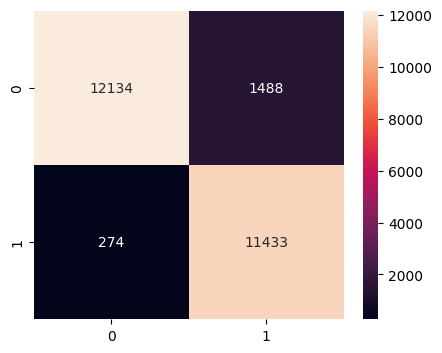

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     13622
           1       0.88      0.98      0.93     11707

    accuracy                           0.93     25329
   macro avg       0.93      0.93      0.93     25329
weighted avg       0.93      0.93      0.93     25329



In [95]:
# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# inference test

In [96]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

# Get I/O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [97]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 2.9 ms, sys: 1 ms, total: 3.9 ms
Wall time: 1.04 ms


In [98]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.996798   0.00320205]
0


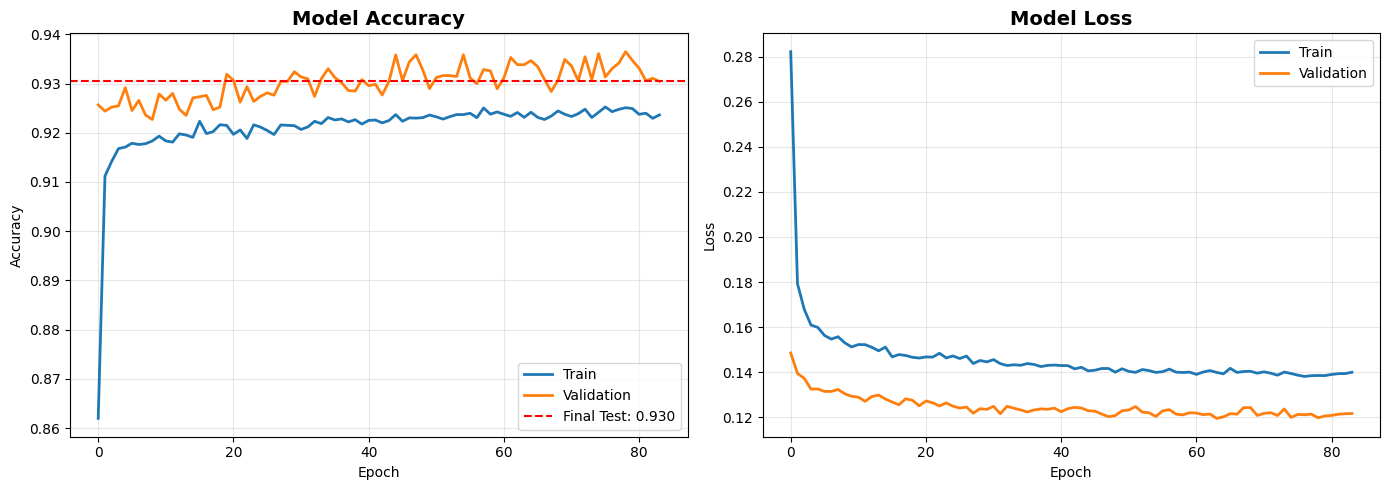

In [105]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.axhline(y=val_acc, color='r', linestyle='--', label=f'Final Test: {val_acc:.3f}')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('back_gesture_training.png', dpi=300)